## Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

Load **Dataset**

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


**Display Sample Images**

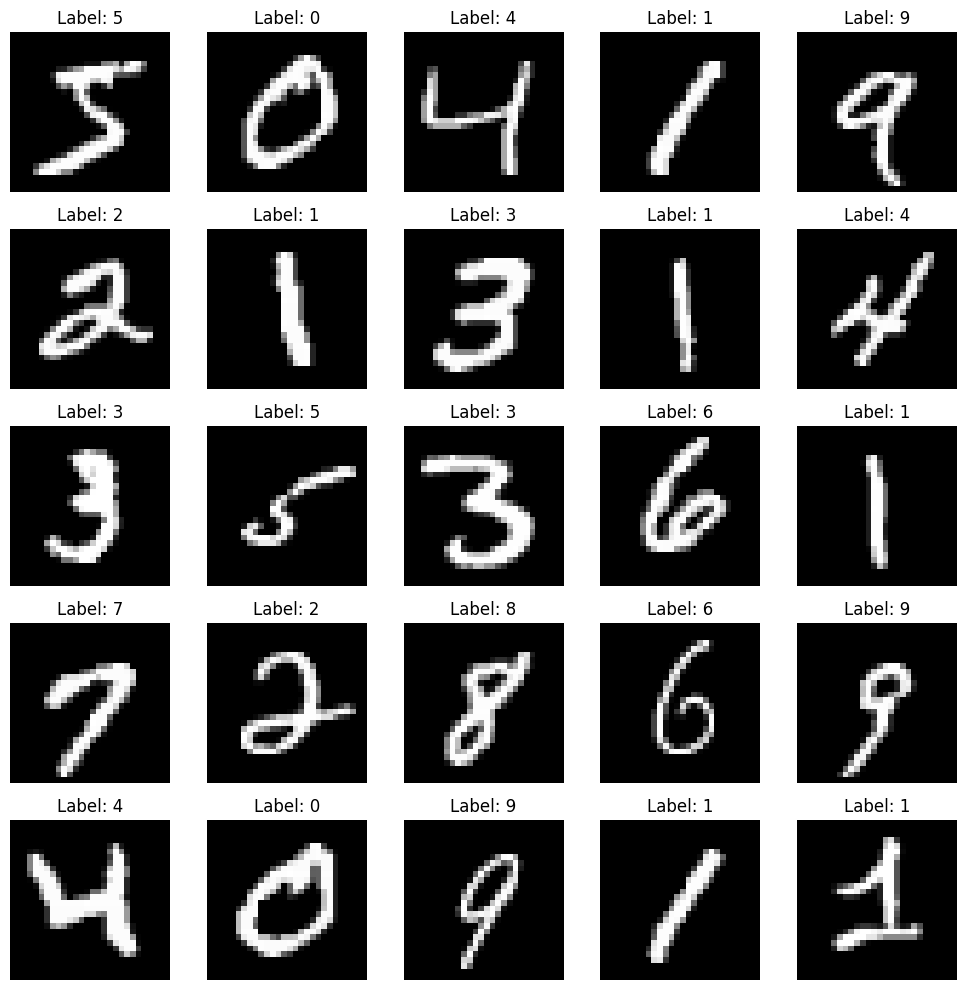

In [ ]:
plt.figure(figsize=(10,10))

for i in range(25):

    plt.subplot(5,5,i+1)

    plt.imshow(x_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")

    plt.axis('off')

plt.tight_layout()
plt.show()

**Data Preprocessing**

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessing Completed")

Preprocessing Completed


**Build Professional CNN Model**

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

**Compile Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


**Add EarlyStopping**

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

**Train Model**

In [ ]:
history = model.fit(

    x_train,
    y_train_cat,

    validation_data=(x_test, y_test_cat),

    epochs=20,
    batch_size=128,

    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9563 - loss: 0.1438 - val_accuracy: 0.7491 - val_loss: 0.9867
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9839 - loss: 0.0551 - val_accuracy: 0.9866 - val_loss: 0.0452
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9895 - loss: 0.0361 - val_accuracy: 0.9892 - val_loss: 0.0356
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9904 - loss: 0.0329 - val_accuracy: 0.9901 - val_loss: 0.0344
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9922 - loss: 0.0257 - val_accuracy: 0.9896 - val_loss: 0.0377
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9930 - loss: 0.0228 - val_accuracy: 0.9922 - val_loss: 0.0279
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9916 - val_loss: 0.0367
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9942 - loss: 0.0184 - val_accuracy:

**Evaluate Model**

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test_cat)

print(f"Test Accuracy: {accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9922 - loss: 0.0279
Test Accuracy: 99.22%


**Accuracy Graph**

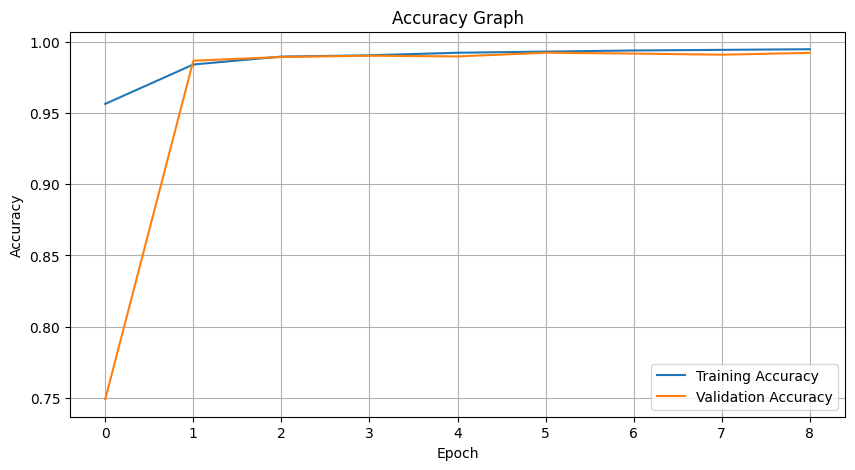

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Graph')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.savefig("accuracy_graph.png")

plt.show()

**Loss Graph**

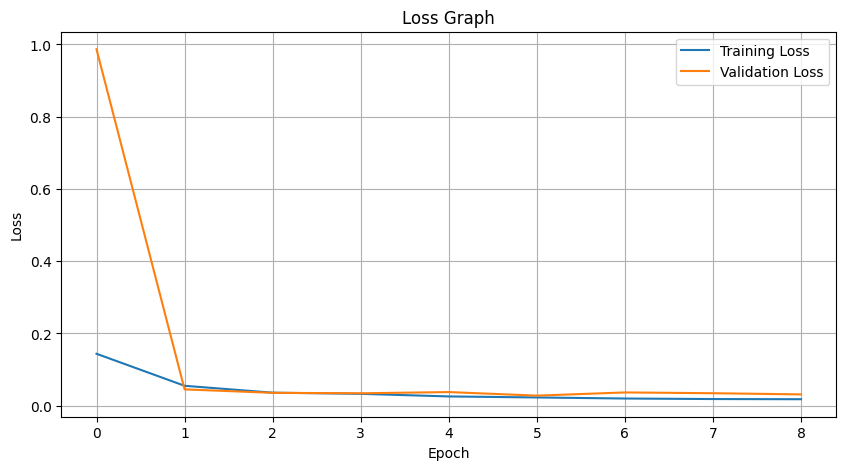

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Graph')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.savefig("loss_graph.png")

plt.show()

**Predictions**

In [ ]:
predicted_digit = np.argmax(prediction)

confidence = np.max(prediction) * 100

predicted_digits.append(
    f"{predicted_digit} ({confidence:.1f}%)"
)

**Confusion Matrix**

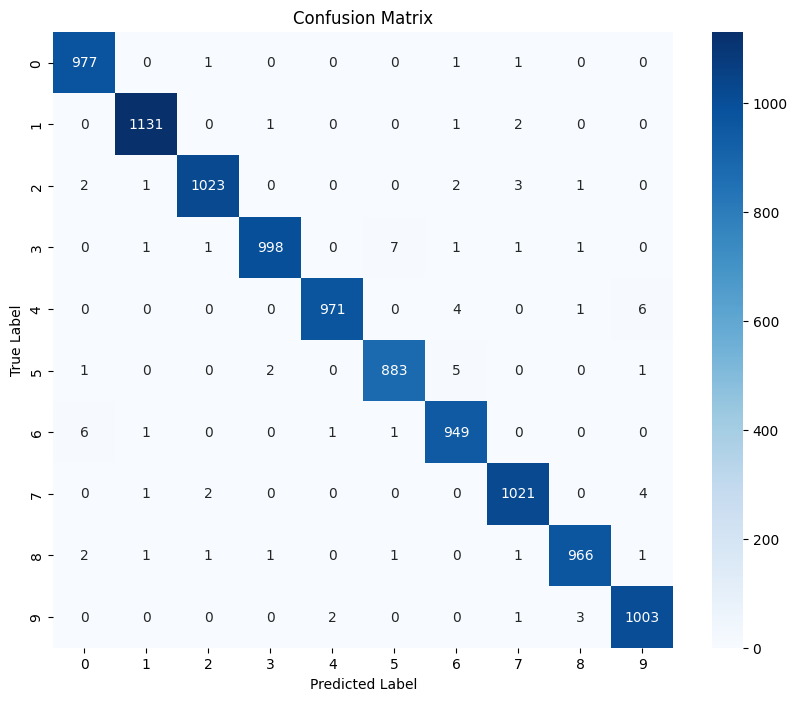

In [ ]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.savefig("confusion_matrix.png")

plt.show()

**Classification Report**

In [ ]:
report = classification_report(y_test, predicted_labels)

print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



**Final Accuracy Score**

In [ ]:
acc = accuracy_score(y_test, predicted_labels)

print("Final Accuracy:", acc)

Final Accuracy: 0.9922


**Display Prediction Examples**

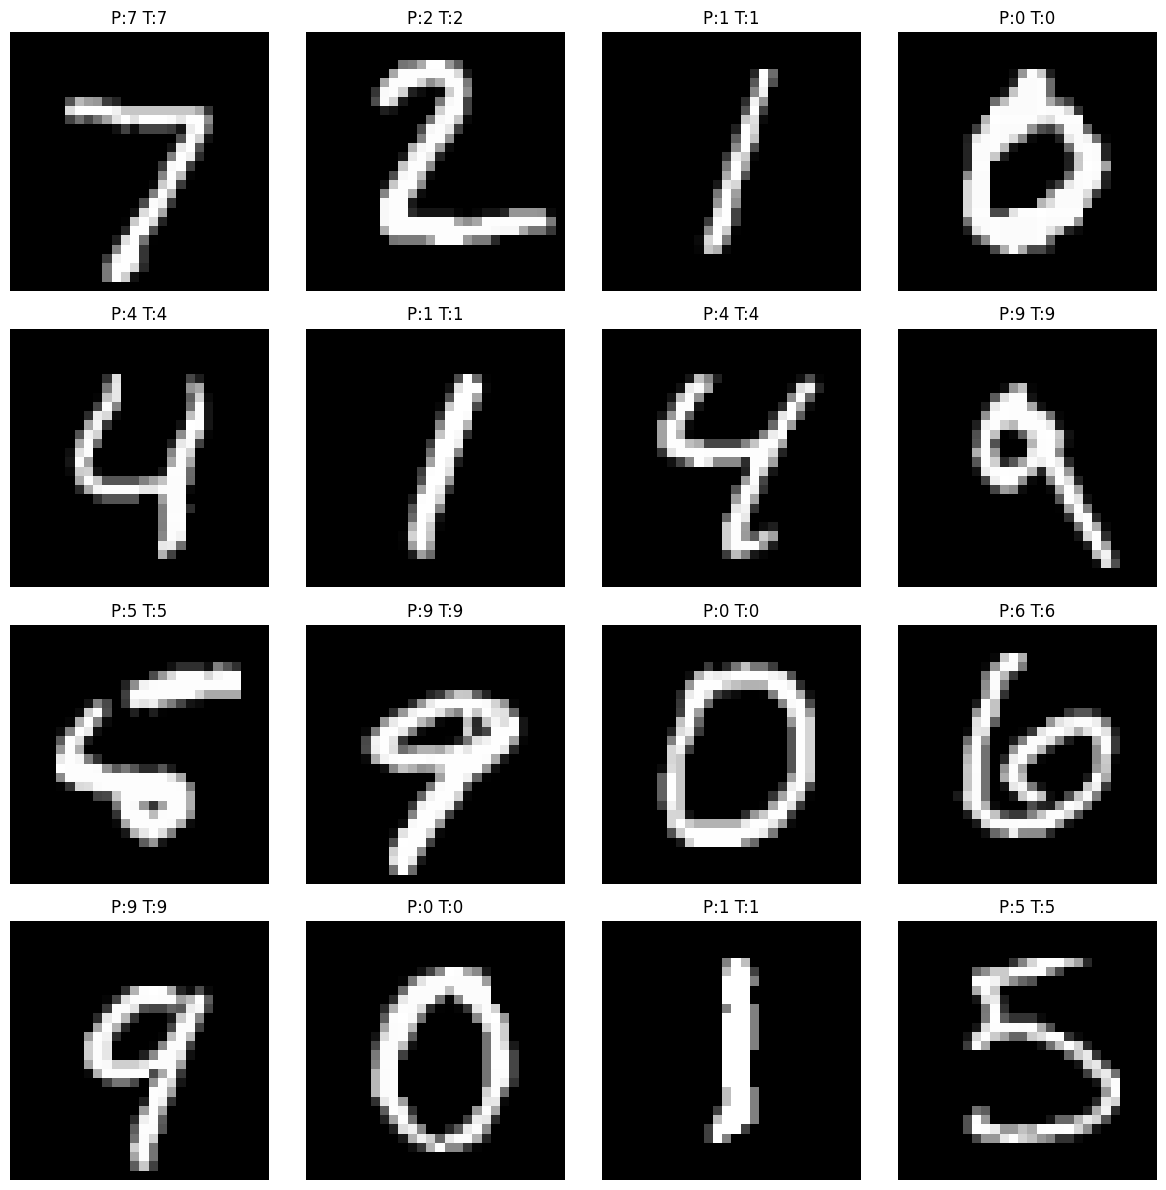

In [ ]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    pred = predicted_labels[i]

    true = y_test[i]

    plt.title(f"P:{pred} T:{true}")

    plt.axis('off')

plt.tight_layout()

plt.show()

**Save** **Model**

In [ ]:
model.save("digit_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


**Upload Custom Image Prediction**

Saving NKw9pkpDsrJ0IUQVCaBtRI5lexK38H2C-doGCMD46eGYlbTA9WUn7eHiKbBiExdX8rHavUHeXwi7sEkLgm_G6nkD5uUHhbEUGtehFtRCrKXmsLvQdAKU-VyJhJgFGzxorEp8JIXsdkp3Afkt3o4-T2TPe2TSxjpmC5Wg9iP9uCADu6bGqY1UWUjfJz1cXAyK.jpg to NKw9pkpDsrJ0IUQVCaBtRI5lexK38H2C-doGCMD46eGYlbTA9WUn7eHiKbBiExdX8rHavUHeXwi7sEkLgm_G6nkD5uUHhbEUGtehFtRCrKXmsLvQdAKU-VyJhJgFGzxorEp8JIXsdkp3Afkt3o4-T2TPe2TSxjpmC5Wg9iP9uCADu6bGqY1UWUjfJz1cXAyK.jpg


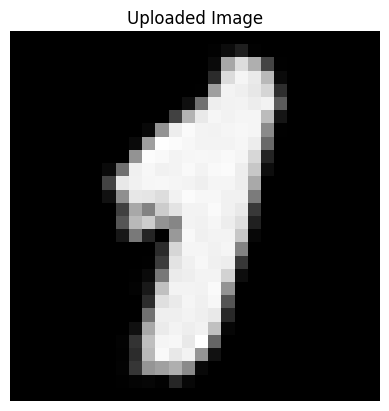

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
Predicted Digit: 1
Confidence: 94.24%


In [ ]:
from google.colab import files
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps



model = load_model('digit_model.h5')



uploaded = files.upload()

for file_name in uploaded.keys():

    image = Image.open(file_name).convert('L')

    image = ImageOps.invert(image)

    image = image.resize((28,28))

    plt.imshow(image, cmap='gray')

    plt.title("Uploaded Image")

    plt.axis('off')

    plt.show()

    image = np.array(image)

    image = image.astype('float32') / 255.0

    image = image.reshape(1,28,28,1)

    prediction = model.predict(image)

    digit = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    print(f"Predicted Digit: {digit}")

    print(f"Confidence: {confidence:.2f}%")

Saving w2GV7_vL8mtuXyaDsJVtfuOneLnYY5dMEvGewOwxlQVOP5fLCRwIGsPRr2ssVVAQvr8PUUIHDLE5cezbHOLrzl2LHroyIt15iklDSD6BQxNS5eyn9ZYdnFe3iUCyO4Gk098R_SyiBL-5WaxmJd5Zg-6DJYmmbsfZzzOYGkqDXOMirkjoMNN4dr2s0jk8VIs6.jpg to w2GV7_vL8mtuXyaDsJVtfuOneLnYY5dMEvGewOwxlQVOP5fLCRwIGsPRr2ssVVAQvr8PUUIHDLE5cezbHOLrzl2LHroyIt15iklDSD6BQxNS5eyn9ZYdnFe3iUCyO4Gk098R_SyiBL-5WaxmJd5Zg-6DJYmmbsfZzzOYGkqDXOMirkjoMNN4dr2s0jk8VIs6 (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


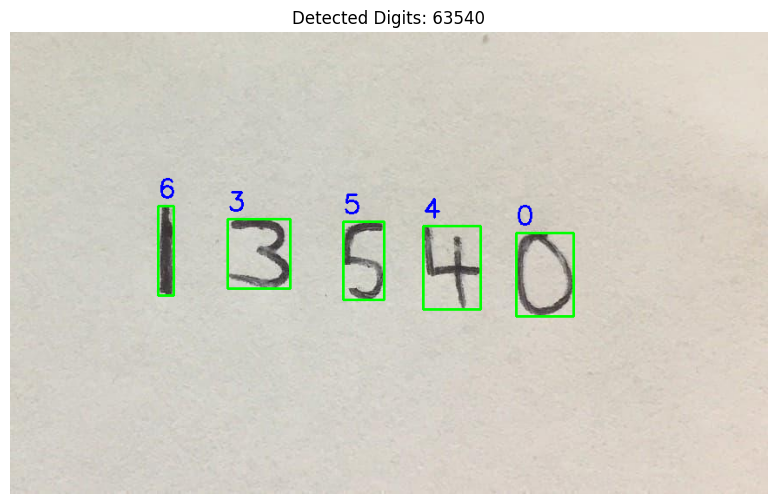

Detected Digits: 63540


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image
from tensorflow.keras.models import load_model

# Load Trained Model
model = load_model('digit_model.h5')

# Upload Image
uploaded = files.upload()

for file_name in uploaded.keys():

    # Read Image
    image = cv2.imread(file_name)

    # Convert to Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Invert Image
    gray = 255 - gray

    # Threshold
    _, thresh = cv2.threshold(
        gray,
        100,
        255,
        cv2.THRESH_BINARY
    )

    # Find Contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    digit_regions = []

    # Draw Contours
    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        # Ignore small noise
        if w > 10 and h > 10:

            digit_regions.append((x, y, w, h))

    # Sort Left to Right
    digit_regions = sorted(digit_regions, key=lambda b: b[0])

    predicted_digits = []

    # Process Each Digit
    for box in digit_regions:

        x, y, w, h = box

        digit = thresh[y:y+h, x:x+w]

        # Resize to 28x28
        digit = cv2.resize(digit, (28,28))

        # Normalize
        digit = digit.astype('float32') / 255.0

        # Reshape
        digit = digit.reshape(1,28,28,1)

        # Predict
        prediction = model.predict(digit)

        predicted_digit = np.argmax(prediction)

        predicted_digits.append(str(predicted_digit))

        # Draw Rectangle
        cv2.rectangle(
            image,
            (x,y),
            (x+w, y+h),
            (0,255,0),
            2
        )
        cv2.putText(
            image,
            str(predicted_digit),
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
          (255,0,0),
          2
        )

    # Show Image
    plt.figure(figsize=(12,6))

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    plt.axis('off')

    plt.title(
        "Detected Digits: " + "".join(predicted_digits)
    )

    plt.show()

    print("Detected Digits:", "".join(predicted_digits))

**REAL-TIME WEBCAM DETECTION**

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load Model
model = load_model('digit_model.h5')

# Webcam
cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    gray = 255 - gray

    _, thresh = cv2.threshold(
        gray,
        100,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        if w > 20 and h > 20:

            digit = thresh[y:y+h, x:x+w]

            digit = cv2.resize(digit, (28,28))

            digit = digit.astype('float32') / 255.0

            digit = digit.reshape(1,28,28,1)

            prediction = model.predict(digit)

            predicted_digit = np.argmax(prediction)

            confidence = np.max(prediction) * 100

            cv2.rectangle(
                frame,
                (x,y),
                (x+w, y+h),
                (0,255,0),
                2
            )

            cv2.putText(
                frame,
                f"{predicted_digit} {confidence:.1f}%",
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (255,0,0),
                2
            )

    # cv2.imshow("Real-Time Digit Recognition", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()

# cv2.destroyAllWindows()

# **Conclusion**

The AI-Based Handwritten Digit Recognition System successfully classifies handwritten digits using Convolutional Neural Networks (CNNs). The model achieved high accuracy on the MNIST dataset and demonstrated efficient image classification capabilities.

This project helped in understanding:
- Deep Learning
- CNN Architecture
- Image Processing
- Model Evaluation
- Computer Vision ***Applications***